<a href="https://colab.research.google.com/github/MartaPCastillo/Tesis/blob/main/Grupo%20M%C3%A9xico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import yfinance as yf # Para descargar datos de acciones
import matplotlib.pyplot as plt
import numpy as np
import math
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf

#Grupo México

In [110]:
#Obtener datos
df = yf.download('GMEXICOB.MX', start='2024-01-01', end ='2026-06-26')

/tmp/ipykernel_3088/382611023.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('GMEXICOB.MX', start='2024-01-01', end ='2026-06-26')
[*********************100%***********************]  1 of 1 completed


In [111]:
print(type(df['Close']))

<class 'pandas.core.frame.DataFrame'>


In [112]:
# Eliminar nivel del ticker
df.columns = df.columns.droplevel(1)

#Análisis de la serie

##Medias Móviles

###Media Móvil Simple

In [113]:
#Calcular Media Móvil Simple de 200 días
df['SMA200'] = df['Close'].rolling(window=200).mean()

<Axes: xlabel='Date'>

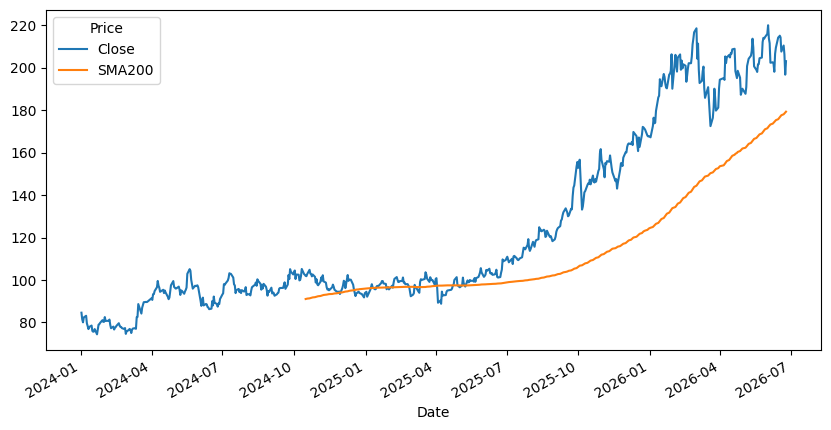

In [114]:
#Visualizar
df[['Close', 'SMA200']].plot(figsize=(10,5))

###Media Móvil Exponencial

In [115]:
#Calcular Media Móvil Exponencial de 200 días
df['EMA200'] = df['Close'].ewm(span=200, adjust=False).mean()

In [116]:
#Calcular Media Móvil Exponencial de 20 días
df['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()

<Axes: xlabel='Date'>

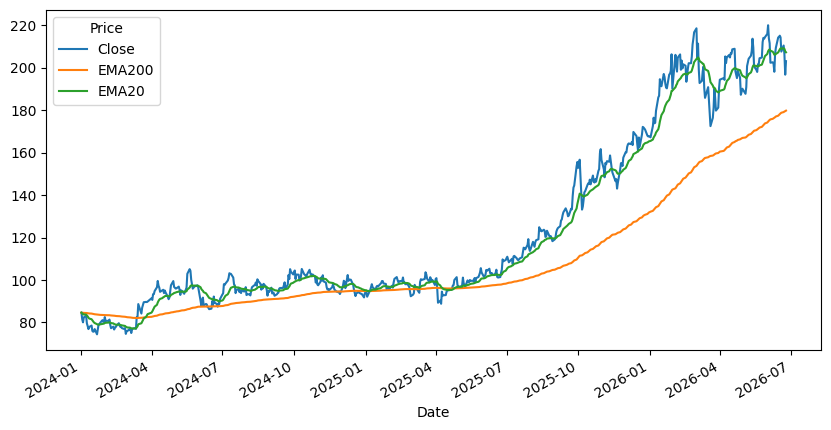

In [117]:
#Visualizar
df[['Close', 'EMA200', 'EMA20']].plot(figsize=(10,5))

##Descomposición Serie Temporal

###Modelo Aditivo

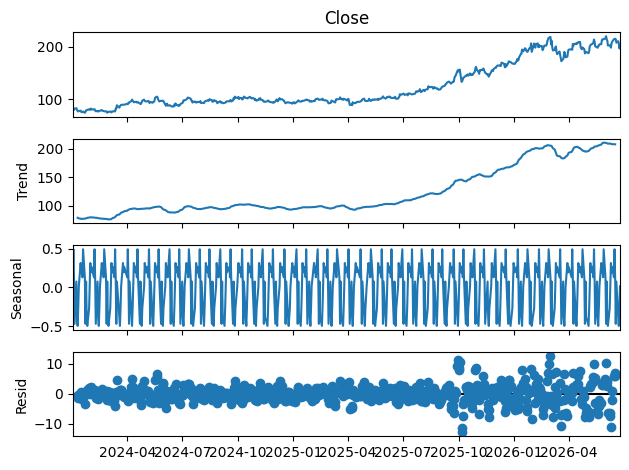

In [118]:
# Descomponer
result = seasonal_decompose(df['Close'], model='additive', period=12) # 12 meses en un año
result.plot()
plt.show()

###Modelo Multiplicativo

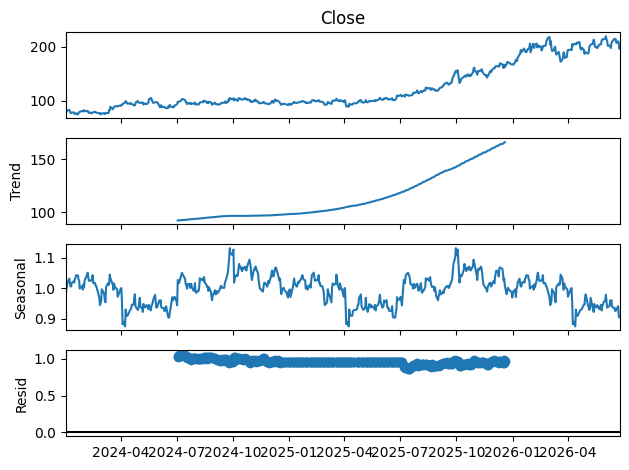

In [119]:
# Descomponer
result = seasonal_decompose(df['Close'], model='multiplicative', period=252) # 252 días hábiles en un año
result.plot()
plt.show()

#Volatilidad

##Desviación Estándar

In [120]:
#Obtener datos
precios = df['Close']

In [121]:
# Método financiero estándar para rendimientos logarítmicos
df['Rendimientos_Log'] = np.log(precios / precios.shift(1))
print(df['Rendimientos_Log'])

Date
2024-01-02         NaN
2024-01-03   -0.037720
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
                ...   
2026-06-19   -0.031826
2026-06-22    0.013689
2026-06-23   -0.020459
2026-06-24   -0.046987
2026-06-25    0.031782
Name: Rendimientos_Log, Length: 621, dtype: float64


In [122]:
#Eliminar NaN solo de rendimientos
df.dropna(subset=['Rendimientos_Log'], inplace=True)
print(df['Rendimientos_Log'])

Date
2024-01-03   -0.037720
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
                ...   
2026-06-19   -0.031826
2026-06-22    0.013689
2026-06-23   -0.020459
2026-06-24   -0.046987
2026-06-25    0.031782
Name: Rendimientos_Log, Length: 620, dtype: float64


In [123]:
#Calcular la desviación estándar de los rendimientos (Volatilidad Diaria)
volatilidad_diaria = df['Rendimientos_Log'].std()
print(f"Volatilidad diaria: {volatilidad_diaria:.4f}")

Volatilidad diaria: 0.0223


In [124]:
#Anualizar la volatilidad (multiplicando por la raíz cuadrada de 252 días hábiles al año)
volatilidad_anual = volatilidad_diaria * np.sqrt(252)
print(f"Volatilidad anualizada: {volatilidad_anual:.4f}")

Volatilidad anualizada: 0.3543


In [125]:
Volatilidad_diaria_porcentaje = volatilidad_diaria * 100
Volatilidad_anual_porcentaje = volatilidad_anual * 100

In [126]:
print(f"Volatilidad diaria: {Volatilidad_diaria_porcentaje:.4f} %")
print(f"Volatilidad anualizada: {Volatilidad_anual_porcentaje:.4f} %")

Volatilidad diaria: 2.2316 %
Volatilidad anualizada: 35.4254 %


##Average True Range

In [127]:
#Calcular los 3 componentes del True Range (TR)
high_low = df['High'] - df['Low']
high_close = np.abs(df['High'] - df['Close'].shift(1))
low_close = np.abs(df['Low'] - df['Close'].shift(1))

In [128]:
print(high_low)

Date
2024-01-03     3.811026
2024-01-04     2.643276
2024-01-05     6.381882
2024-01-08     2.570863
2024-01-09     4.200276
                ...    
2026-06-19     8.240005
2026-06-22     7.779999
2026-06-23     9.880005
2026-06-24    10.000000
2026-06-25     8.190002
Length: 620, dtype: float64


In [129]:
print(high_close)

Date
2024-01-03         NaN
2024-01-04    0.117682
2024-01-05    6.046948
2024-01-08    0.887134
2024-01-09    0.253468
                ...   
2026-06-19    0.399994
2026-06-22    3.880005
2026-06-23    1.550003
2026-06-24    1.100006
2026-06-25    8.050003
Length: 620, dtype: float64


In [130]:
print(low_close)

Date
2024-01-03          NaN
2024-01-04     2.525594
2024-01-05     0.334934
2024-01-08     1.683729
2024-01-09     3.946808
                ...    
2026-06-19     7.840012
2026-06-22     3.899994
2026-06-23    11.430008
2026-06-24    11.100006
2026-06-25     0.139999
Length: 620, dtype: float64


In [131]:
#Unir y obtener el máximo de los 3 para cada día
ranges = pd.concat([high_low, high_close, low_close], axis=1)
true_range = ranges.max(axis=1)

In [132]:
print(true_range)

Date
2024-01-03     3.811026
2024-01-04     2.643276
2024-01-05     6.381882
2024-01-08     2.570863
2024-01-09     4.200276
                ...    
2026-06-19     8.240005
2026-06-22     7.779999
2026-06-23    11.430008
2026-06-24    11.100006
2026-06-25     8.190002
Length: 620, dtype: float64


In [133]:
#Calcular el ATR (suavizado clásico de Wilder, n=14)
atr_period = 14
atr = true_range.copy()

In [134]:
#El primer ATR es la media simple de los primeros 14 días
atr.iloc[atr_period-1] = true_range.iloc[:atr_period].mean()

In [135]:
#Iterar para aplicar la fórmula suavizada
for i in range(atr_period, len(true_range)):
    atr.iloc[i] = (atr.iloc[i-1] * (atr_period - 1) + true_range.iloc[i]) / atr_period

df['ATR_Calculado'] = atr
print(df[['High', 'Low', 'Close', 'ATR_Calculado']].tail())

Price             High         Low       Close  ATR_Calculado
Date                                                         
2026-06-19  214.610001  206.369995  207.500000       7.544827
2026-06-22  211.380005  203.600006  210.360001       7.561625
2026-06-23  208.809998  198.929993  206.100006       7.837938
2026-06-24  205.000000  195.000000  196.639999       8.070943
2026-06-25  204.690002  196.500000  202.990005       8.079447


In [136]:
#ATR diario
atr_diario = atr.mean()
print(f"ATR diario: ${atr_diario:.4f}")

ATR diario: $4.2903


In [137]:
#ATR Anualizado
atr_anualizado = atr.mean() * np.sqrt(252)
print(f"ATR anualizado: ${atr_anualizado:.4f}")

ATR anualizado: $68.1064


In [138]:
# Obtener el último precio de cierre (el del 26/06/26)
precio_cierre_final = df['Close'].iloc[-1]
print("El último precio de cierre es: $", precio_cierre_final)

El último precio de cierre es: $ 202.99000549316406


In [139]:
#Convertimos en porcentaje ya que lo anterior es calculado con precios de cierre
ATR_diario_porcentaje = (atr_diario/precio_cierre_final) * 100
ATR_anualizado_porcentaje = (atr_anualizado/precio_cierre_final) * 100

In [140]:
print(f"ATR diario: {ATR_diario_porcentaje:.4f} %")
print(f"ATR anualizado: {ATR_anualizado_porcentaje:.4f} %")

ATR diario: 2.1136 %
ATR anualizado: 33.5516 %


#Parámetros (p,d,q)

##Estacionariedad

###Prueba Dickey Fuller

In [141]:
# Función para realizar la prueba de Dickey-Fuller Aumentada
def probar_estacionariedad(serie, titulo):
    print(f"\n--- Prueba ADF para: {titulo} ---")
    resultado = adfuller(serie.dropna())
    estadistico = resultado[0]
    valor_p = resultado[1]
    criticos = resultado[4]

    print(f"Estadístico de Dickey-Fuller: {estadistico:.4f}")
    print(f"Valor p: {valor_p:.4f}")

    if valor_p < 0.05:
        print("Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).")
    else:
        print("Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).")

    return valor_p

In [142]:
#Obtener datos precios de cierre originales
precios = df['Close']

In [143]:
# Ejecutar prueba en Precios (Original)
probar_estacionariedad(precios, "Precios de Cierre (Original)")


--- Prueba ADF para: Precios de Cierre (Original) ---
Estadístico de Dickey-Fuller: 0.2948
Valor p: 0.9771
Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).


np.float64(0.9771046796736259)

In [144]:
#Prueba de estacionariedad (Dickey-Fuller Aumentada) a los rendimientos logarítmicos
probar_estacionariedad(df['Rendimientos_Log'], "Retornos Logarítmicos")


--- Prueba ADF para: Retornos Logarítmicos ---
Estadístico de Dickey-Fuller: -27.1185
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0

###Función de Autocorrelación

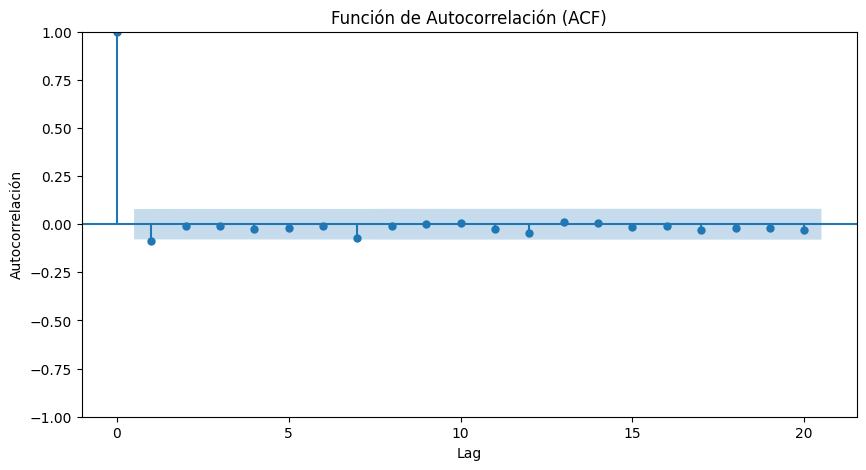

In [145]:
#Gráfica ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(df['Rendimientos_Log'], lags=20, ax=ax)
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelación")
ax.set_title("Función de Autocorrelación (ACF)")
plt.show()

###Función de Autocorrelación Parcial

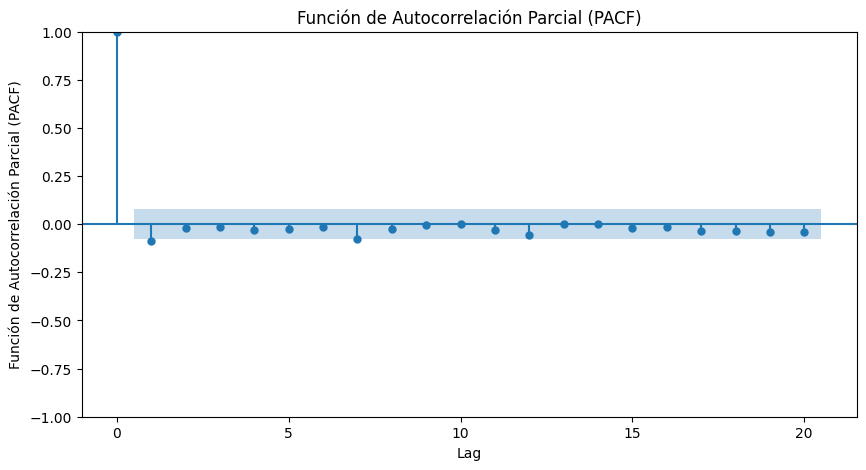

In [146]:
#Gráfica PACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(df['Rendimientos_Log'], lags=20, ax=ax)
ax.set_xlabel("Lag")
ax.set_ylabel("Función de Autocorrelación Parcial (PACF)")
ax.set_title("Función de Autocorrelación Parcial (PACF)")
plt.show()